## Étape 2 : Assemble Data

In [1]:
from datasets import load_dataset
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import json
from dotenv.ipython import load_dotenv
from langchain_openai import ChatOpenAI
from tqdm import tqdm

d:\MesDoc\1-II-BDCC\3-S3\Agentic AI\TPs\TP1-SMA-Sentiment-Analysis\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
ds=load_dataset("imdb")

In [3]:
ds

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})

In [4]:
train_df=ds["train"].to_pandas()

In [5]:
train_df.sample(10)

,text,label
6704,The best thing I can say about this film is th...,0
2189,"The ultimate goal of Big Brother, that we know...",0
24965,Rented and watched this short (< 90 minutes) w...,1
19962,"""The Notorious Bettie Page"" (2005) <br /><br /...",1
11842,Can anybody do good CGI films besides Pixar? I...,0
18649,This picture for me scores very highly as it i...,1
20118,/The first episode I saw of Lost made me think...,1
7374,"I absolutely hate this programme, what kind of...",0
14418,I saw this movie Sunday afternoon. I absolutel...,1
23789,A superb and compelling drama about the hunt f...,1


In [6]:
train_df['label'].value_counts()

label
0    12500
1    12500
Name: count, dtype: int64

In [7]:
train_df['sentiment'] = np.where(train_df['label'] == 1, 'positive', 'negative')

In [8]:
train_df

,text,label,sentiment
0,I rented I AM CURIOUS-YELLOW from my video sto...,0,negative
1,"""I Am Curious: Yellow"" is a risible and preten...",0,negative
2,If only to avoid making this type of film in t...,0,negative
3,This film was probably inspired by Godard's Ma...,0,negative
4,"Oh, brother...after hearing about this ridicul...",0,negative
...,...,...,...
24995,A hit at the time but now better categorised a...,1,positive
24996,I love this movie like no other. Another time ...,1,positive
24997,This film and it's sequel Barry Mckenzie holds...,1,positive
24998,'The Adventures Of Barry McKenzie' started lif...,1,positive


In [9]:
train_df.sentiment.value_counts()

sentiment
negative    12500
positive    12500
Name: count, dtype: int64

<Axes: >

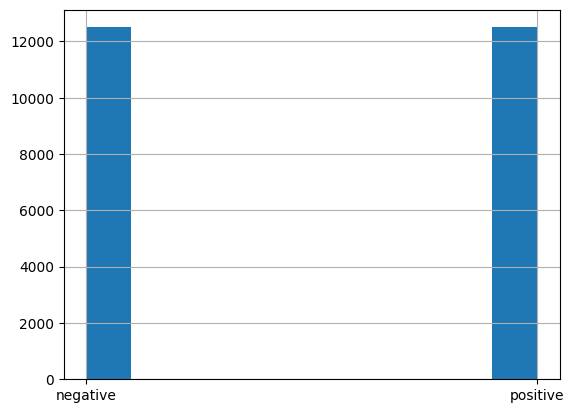

In [10]:
train_df.sentiment.hist()

In [11]:
examples_df, gold_examples_df = train_test_split(
    train_df, test_size=0.2, random_state=123
)

In [12]:
examples_df.shape , gold_examples_df.shape

((20000, 3), (5000, 3))

In [13]:
columns=["text","sentiment"]
gold_examples= (gold_examples_df[columns]
                .sample(20, random_state=34)
                .to_json(orient="records")
                )

In [14]:
json.loads(gold_examples)[0]

{'text': '"A Guy Thing" may not be a classic, but it sure is a good, funny comedy. The plot focuses on Paul (Jason Lee), who wakes up the morning after his bachelor party with no memory and Becky (Julia Stiles) lying naked in his bed. Before he can figure out what happened, he rushes Becky out of his apartment because his fiance Karen (Selma Blair) is coming. After that, as you could imagine, chaos ensues.<br /><br />Almost every single scene in "A Guy Thing" delivers loud laughs. The funniest moments come from when Paul imagines what could happen if he tells Karen. Selma Blair is a truly talented comedian, and the worst thing about this film is that she goes underused. Although, she turns out to be more funny than Stiles\' character, who actually isn\'t that interesting. Of course, not every comedy is perfect.<br /><br />As I said, "A Guy Thing" is no classic, but it\'s not bad either, 7/10.',
 'sentiment': 'positive'}

## Étape 3 : Élaborer le prompt

In [15]:
user_prompt_template = """```{movie_review}```"""

In [16]:
zero_shot_system_message =""""
Classify the sentiment of movie reviews presented in the input as 'positive' or 'negative'
Movie reviews will be delimited by triple backticks in the input.
Answer only 'positive' or 'negative'
Do not explain your answer.
"""

In [17]:
zero_shot_prompt = [{'role':'system', 'content': zero_shot_system_message}]

In [18]:
few_shot_system_message ="""
Classify the sentiment of movie reviews presented in the input as 'positive' or 'negative'
Movie reviews will be delimited by triple backticks in the input.
Answer only 'positive' or 'negative'
Do not explain your answer.
"""

In [19]:
examples_df.shape

(20000, 3)

In [20]:
positive_reviews_df=(examples_df[examples_df['sentiment']=='positive'][columns]
                     .sample(4, random_state=34)
                     )

In [21]:
negative_reviews_df=(examples_df[examples_df['sentiment']=='negative'][columns]
                     .sample(4, random_state=34)
                     )

In [22]:
negative_reviews_df

,text,sentiment
2786,Do we really need any more narcissistic garbag...,negative
991,"This movie is so awful, it is hard to find the...",negative
12145,I had high hopes for Troy and I am so bitterly...,negative
11534,If I could i would give ZERO stars for this on...,negative


In [23]:
positive_reviews_df

,text,sentiment
14351,I went to see Antone Fisher not knowing what t...,positive
13676,This is a very good movie. Do you want to know...,positive
21696,Several story lines are interwoven here around...,positive
14251,"""I moved out here to get away from this kind o...",positive


In [24]:
positive_reviews_df.shape, negative_reviews_df.shape

((4, 2), (4, 2))

In [25]:
ex=pd.concat([positive_reviews_df, negative_reviews_df])

In [26]:
ex

,text,sentiment
14351,I went to see Antone Fisher not knowing what t...,positive
13676,This is a very good movie. Do you want to know...,positive
21696,Several story lines are interwoven here around...,positive
14251,"""I moved out here to get away from this kind o...",positive
2786,Do we really need any more narcissistic garbag...,negative
991,"This movie is so awful, it is hard to find the...",negative
12145,I had high hopes for Troy and I am so bitterly...,negative
11534,If I could i would give ZERO stars for this on...,negative


In [27]:
examples= examples_df.sample(4*2, replace=False).to_json(orient="records")

In [28]:
json.loads(examples)

[{'text': 'I vowed a long time ago to NEVER, EVER watch a movie that has ANYONE who EVER was a regular cast member of "Saturday Night Live". I didn\'t rent "Corky Romano" but I was forced by my unfailing good manners to watch it for half an hour. Then my good manners failed. Stupid, not funny. Tedious, not hilarious. Bad, not good. That in a nutshell is all I can say for this video.',
  'label': 0,
  'sentiment': 'negative'},
 {'text': 'This is a really fun movie. One of those you can sit and mindlessly watch as the plot gets more and more twisted; more and more funny. Sally Field, Teri Hatcher (in her hey-day), Kevin Klein, Elisabeth Shue, Robert Downey, Jr...It\'s all these well-known, quality actors acting as if they are soap opera stars/producers. If you have ever watched a soap opera and thought, "How on earth did they come up with THIS idea??", you will LOVE this movie. I have seen it multiple times; and each time I watch it, the more I appreciate the humor, the more I realize ju

In [32]:
def create_examples(dataset, n=4):
    positive_reviews_df=(dataset[dataset['sentiment']=='positive'][columns]
                     .sample(n, random_state=34)
                     )
    negative_reviews_df=(dataset[dataset['sentiment']=='negative'][columns]
                     .sample(n, random_state=34)
                     )
    examples_df=pd.concat([positive_reviews_df, negative_reviews_df])
    examples= examples_df.sample(2*n, replace=False)
    return examples.to_json(orient="records")

In [33]:
examples_df.shape

(20000, 3)

In [34]:
few_shot_examples=create_examples(examples_df, n=2)


In [35]:
json.loads(few_shot_examples)

[{'text': "I went to see Antone Fisher not knowing what to expect and was most pleasantly surprised. The acting job by Derek Luke was outstanding and the story line was excellent. Of course Denzel Washington did his usual fine job of acting as well as directing. It makes you realized that people with mental problems CAN be helped and this movie is a perfect example of this. Don't miss this one.",
  'sentiment': 'positive'},
 {'text': 'This movie is so awful, it is hard to find the right words to describe it!<br /><br />At first the story is so ridiculous.A narrow-minded human can write a better plot! The actors are boring and untalented, perhaps they were compelled to play in this cheesy Film.<br /><br />The camera receptions of the National Forest are the only good in this whole movie. I should feel ashame, because I paid for this lousy Picture.<br /><br />Hopefully nobody makes a sequel or make a similar film with such a worse storyline :-)',
  'sentiment': 'negative'},
 {'text': "Th

In [36]:
def creat_prompt(system_message, examples, user_prompt_template):
    prompt=[
        {'role':'system', 'content': system_message},
    ]
    for example in json.loads(examples) :
        review=example['text']
        sentiment=example['sentiment']
        prompt.append({'role':'user', 'content': user_prompt_template.format(movie_review=review) })
        prompt.append({'role':'assistant', 'content': f"{sentiment}"})
    return prompt

In [37]:
few_shot_prompt = creat_prompt(few_shot_system_message, few_shot_examples, user_prompt_template)

In [38]:
few_shot_prompt

[{'role': 'system',
  'content': "\nClassify the sentiment of movie reviews presented in the input as 'positive' or 'negative'\nMovie reviews will be delimited by triple backticks in the input.\nAnswer only 'positive' or 'negative'\nDo not explain your answer.\n"},
 {'role': 'user',
  'content': "```I went to see Antone Fisher not knowing what to expect and was most pleasantly surprised. The acting job by Derek Luke was outstanding and the story line was excellent. Of course Denzel Washington did his usual fine job of acting as well as directing. It makes you realized that people with mental problems CAN be helped and this movie is a perfect example of this. Don't miss this one.```"},
 {'role': 'assistant', 'content': 'positive'},
 {'role': 'user',
  'content': '```This movie is so awful, it is hard to find the right words to describe it!<br /><br />At first the story is so ridiculous.A narrow-minded human can write a better plot! The actors are boring and untalented, perhaps they were

## Etape 4 : Evaluate Prompts

In [39]:
cot_few_shot_prompt_system_message = """
Classify the sentiment of movie reviews presented in the input
as 'positive' or 'negative'
Movie reviews will be delimited by triple backticks ``` in the
input.
Answer only 'positive' or 'negative'
Do not explain your answer.

Instructions:
1. Carefully read the text of the review and think through the options for sentiment provided
2. Consider the overall sentiment of the review and estimate the probability of the review being positive 

To reiterate, your answer should strictly only contain the label: positive or negative

"""

In [40]:
cot_few_shot_prompt= creat_prompt(cot_few_shot_prompt_system_message
                                  ,few_shot_examples
                                  ,user_prompt_template)

In [41]:
cot_few_shot_prompt

[{'role': 'system',
  'content': "\nClassify the sentiment of movie reviews presented in the input\nas 'positive' or 'negative'\nMovie reviews will be delimited by triple backticks ``` in the\ninput.\nAnswer only 'positive' or 'negative'\nDo not explain your answer.\n\nInstructions:\n1. Carefully read the text of the review and think through the options for sentiment provided\n2. Consider the overall sentiment of the review and estimate the probability of the review being positive \n\nTo reiterate, your answer should strictly only contain the label: positive or negative\n\n"},
 {'role': 'user',
  'content': "```I went to see Antone Fisher not knowing what to expect and was most pleasantly surprised. The acting job by Derek Luke was outstanding and the story line was excellent. Of course Denzel Washington did his usual fine job of acting as well as directing. It makes you realized that people with mental problems CAN be helped and this movie is a perfect example of this. Don't miss this

In [42]:
from sklearn.metrics import f1_score

In [ ]:
def evaluate_prompt(prompt,gold_examples,user_prompt_template,llm):
    predicted_sentiments=[]
    ground_truth_sentiment = []
    for exemple in json.loads(gold_examples):
        review= exemple['text']
        sentiment = exemple['sentiment']
        user_input = [{"role" :"user" , "content" : user_prompt_template.format(movie_review=review)}]
        try :
            resp=llm.invoke(prompt+user_input)
            if 'negative' in resp.content.strip().lower():
                predicted= 'negative'
            elif 'positive' in resp.content.strip().lower():
                predicted= 'positive'
            else :
                predicted='unknown'
            predicted_sentiments.append(predicted)
            ground_truth_sentiment.append(sentiment)
            #print (predicted, sentiment)
        except Exception as e :
            print(e)
            continue
    return f1_score(ground_truth_sentiment,predicted_sentiments,average='micro')
    

In [ ]:
load_dotenv(override=True)

In [ ]:
llm1 = ChatOpenAI(model="gpt-4o",temperature=0)

In [ ]:
evaluate_prompt(zero_shot_prompt,gold_examples , user_prompt_template ,llm1)

In [ ]:
evaluate_prompt(few_shot_prompt,gold_examples , user_prompt_template ,llm1)

In [ ]:
evaluate_prompt(cot_few_shot_prompt,gold_examples , user_prompt_template ,llm1)

In [ ]:
from langchain_ollama import ChatOllama

In [ ]:
llm2 = ChatOllama(model="llama3.2", temperature=0)  

In [ ]:
evaluate_prompt(cot_few_shot_prompt,gold_examples , user_prompt_template ,llm2)

In [ ]:
evaluate_prompt(zero_shot_prompt,gold_examples , user_prompt_template ,llm2)

In [ ]:
evaluate_prompt(few_shot_prompt,gold_examples , user_prompt_template ,llm2)

In [ ]:
num_evel_runs=10
performances=[]

for _ in tqdm(range(num_evel_runs)) :
    examples = create_examples(examples_df,n=4)
    fsp = creat_prompt(few_shot_system_message,examples, user_prompt_template)
    score=evaluate_prompt(fsp,gold_examples,user_prompt_template,llm1)
    performances.append(score)

mean= np.array(performances).mean()
std= np.array(performances).std()

print(f"Mean : {mean} , std : {std}")
